In [46]:
# ============================================================
# 1. LOAD EARTHQUAKE DATASET
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ask the user to upload the earthquake CSV file
from google.colab import files

uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Read the CSV file
df = pd.read_csv(file_name)

# Display the first 5 records
print(df.head())


Saving earthquake_data.csv to earthquake_data (2).csv
                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia        6.9  18-11-2022 13:37   
2                                      M 7.0 -         7.0  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga        7.3  11-11-2022 10:48   
4                                      M 6.6 -         6.6  09-11-2022 10:14   

   cdi  mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  \
0    8    7  green        1  768  us  117  0.509  17.0     mww   14.000   
1    4    4  green        0  735  us   99  2.229  34.0     mww   25.000   
2    3    3  green        1  755  us  147  3.125  18.0     mww  579.000   
3    5    5  green        1  833  us  149  1.865  21.0     mww   37.000   
4    0    2  green        1  670  us  131  4.998  27.0     mww  624.464   

   latitude  l

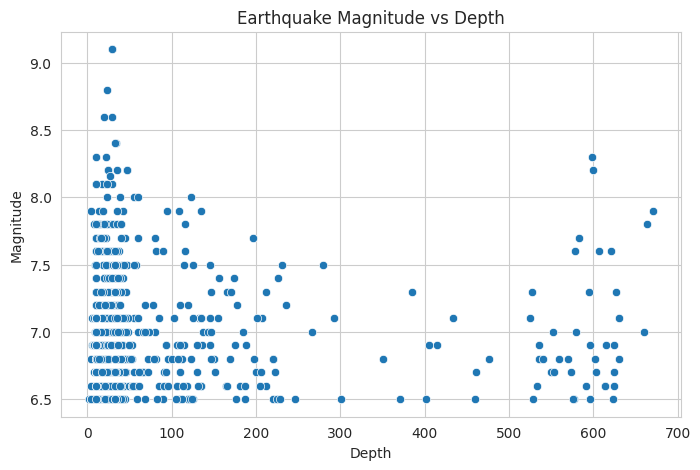

In [47]:
# ============================================================
# 2. MAGNITUDE VS DEPTH - SCATTER PLOT
# ============================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="depth",
    y="magnitude"
)

plt.title("Earthquake Magnitude vs Depth")
plt.xlabel("Depth")
plt.ylabel("Magnitude")

plt.show()


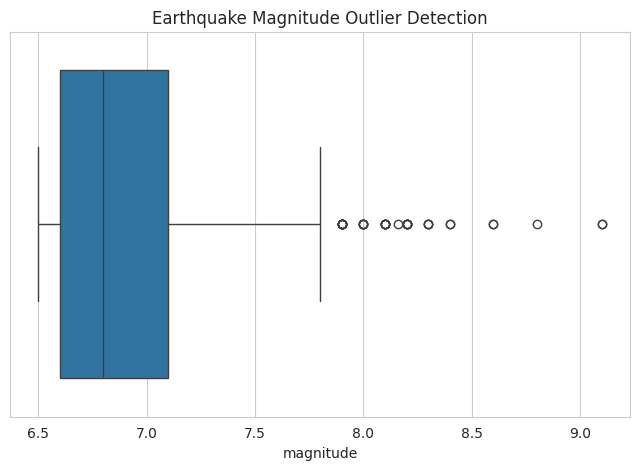

In [48]:
# ============================================================
# 3. MAGNITUDE OUTLIER DETECTION - BOXPLOT
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(x=df["magnitude"])

plt.title("Earthquake Magnitude Outlier Detection")

plt.show()

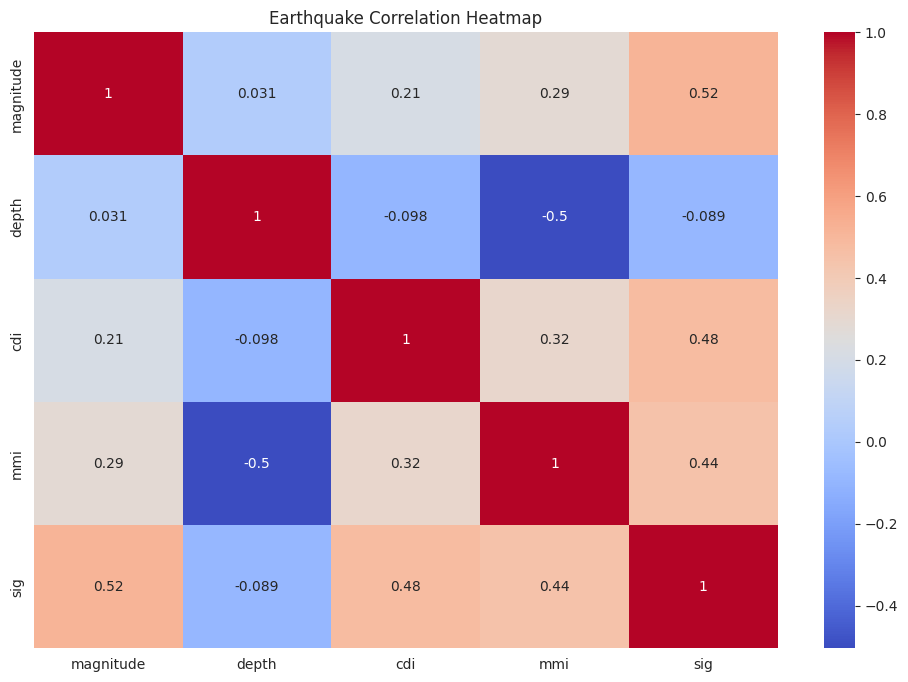

In [49]:
# ============================================================
# 4. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12,8))

corr = df[
    ["magnitude", "depth", "cdi", "mmi", "sig"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Earthquake Correlation Heatmap")

plt.show()

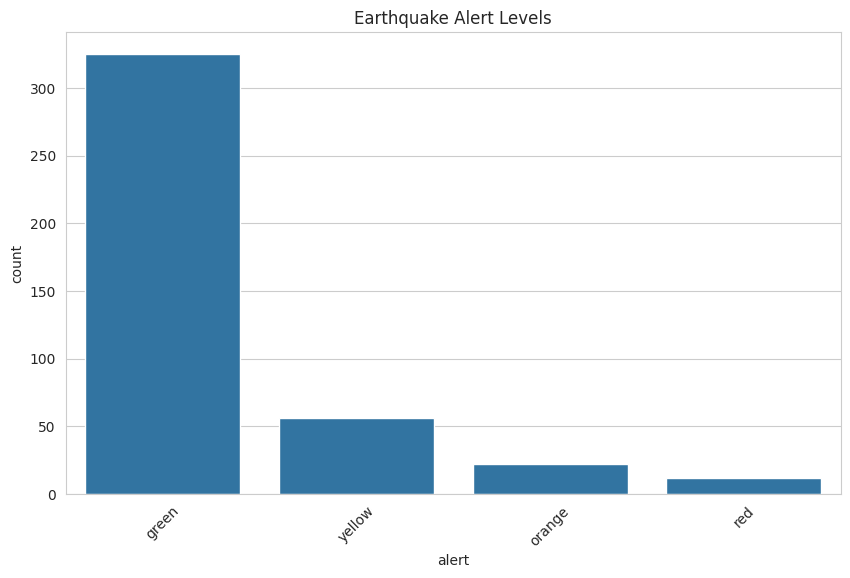

In [50]:
# ============================================================
# 5. EARTHQUAKE COUNT BY ALERT LEVEL
# ============================================================

sns.countplot(
    data=df,
    x="alert"
)

plt.xticks(rotation=45)

plt.title("Earthquake Alert Levels")

plt.show()


/tmp/ipykernel_1133/295277352.py:5: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date_time"] = pd.to_datetime(df["date_time"])


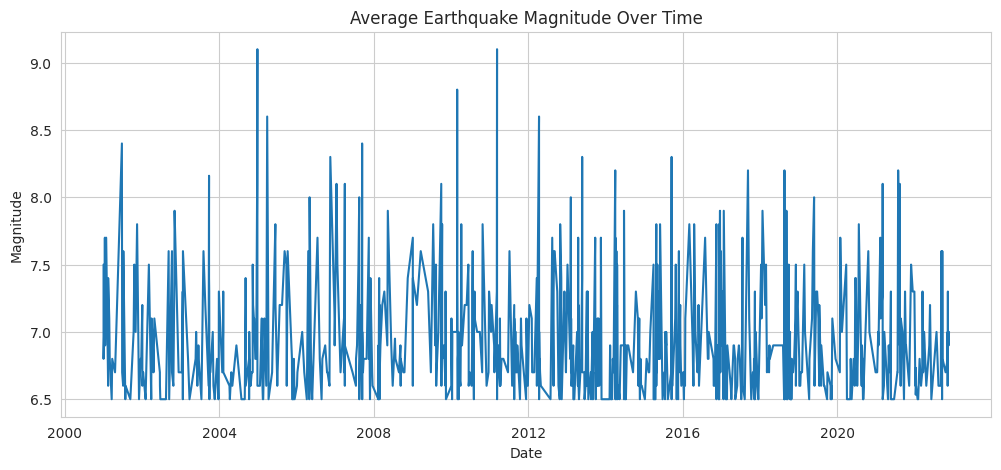

In [51]:
# ============================================================
# 6. AVERAGE MAGNITUDE OVER TIME
# ============================================================

df["date_time"] = pd.to_datetime(df["date_time"])

daily = df.groupby("date_time")["magnitude"].mean()

plt.figure(figsize=(12,5))

plt.plot(
    daily
)

plt.title("Average Earthquake Magnitude Over Time")

plt.xlabel("Date")

plt.ylabel("Magnitude")

plt.show()


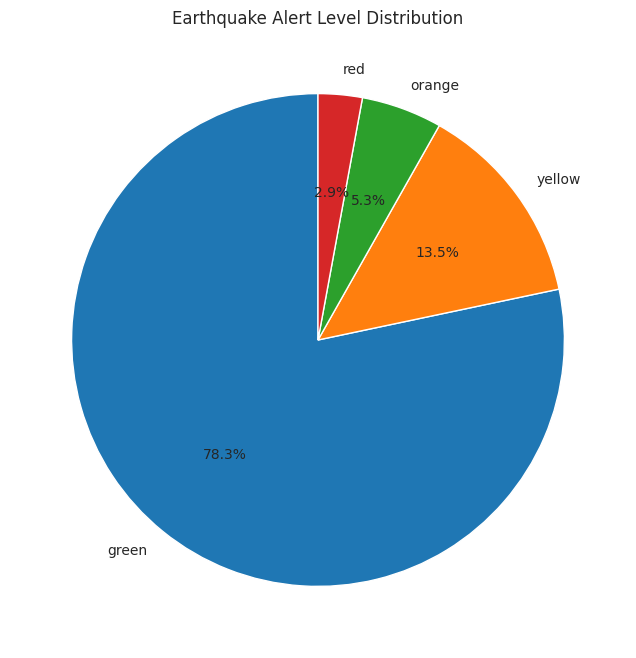

In [52]:
# ============================================================
# 7. ALERT LEVEL DISTRIBUTION
# ============================================================

alert = df["alert"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    alert,
    labels=alert.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Earthquake Alert Level Distribution")

plt.show()

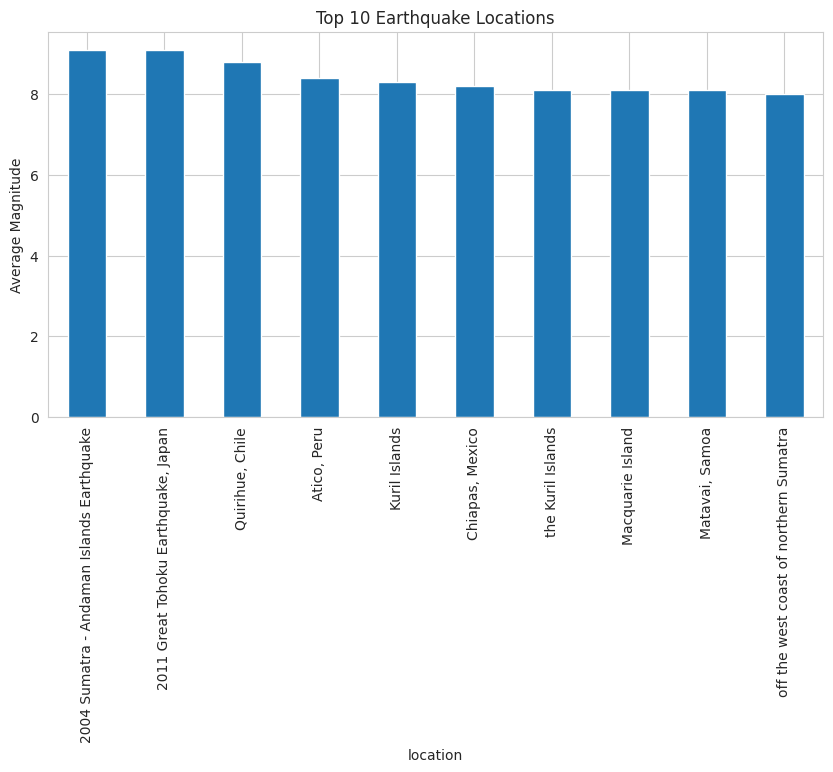

In [53]:
# ============================================================
# 8. TOP 10 LOCATIONS WITH MOST EARTHQUAKES
# ============================================================

location = df.groupby("location")["magnitude"].mean()

location = location.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

location.plot(kind="bar")

plt.title("Top 10 Earthquake Locations")

plt.ylabel("Average Magnitude")

plt.show()

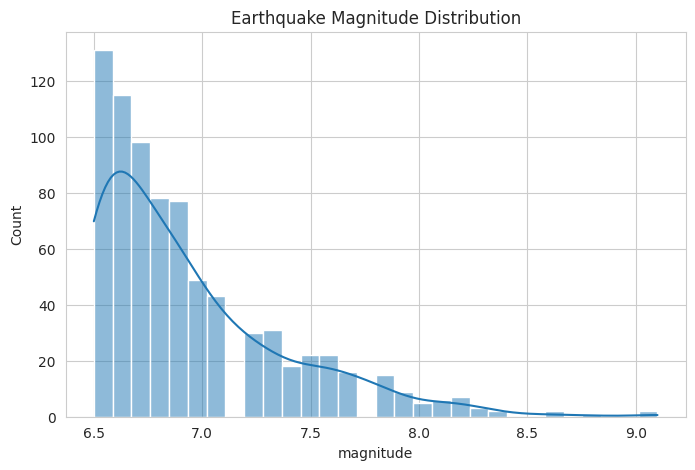

In [54]:
# ============================================================
# 9. EARTHQUAKE MAGNITUDE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["magnitude"],
    bins=30,
    kde=True
)

plt.title("Earthquake Magnitude Distribution")

plt.show()


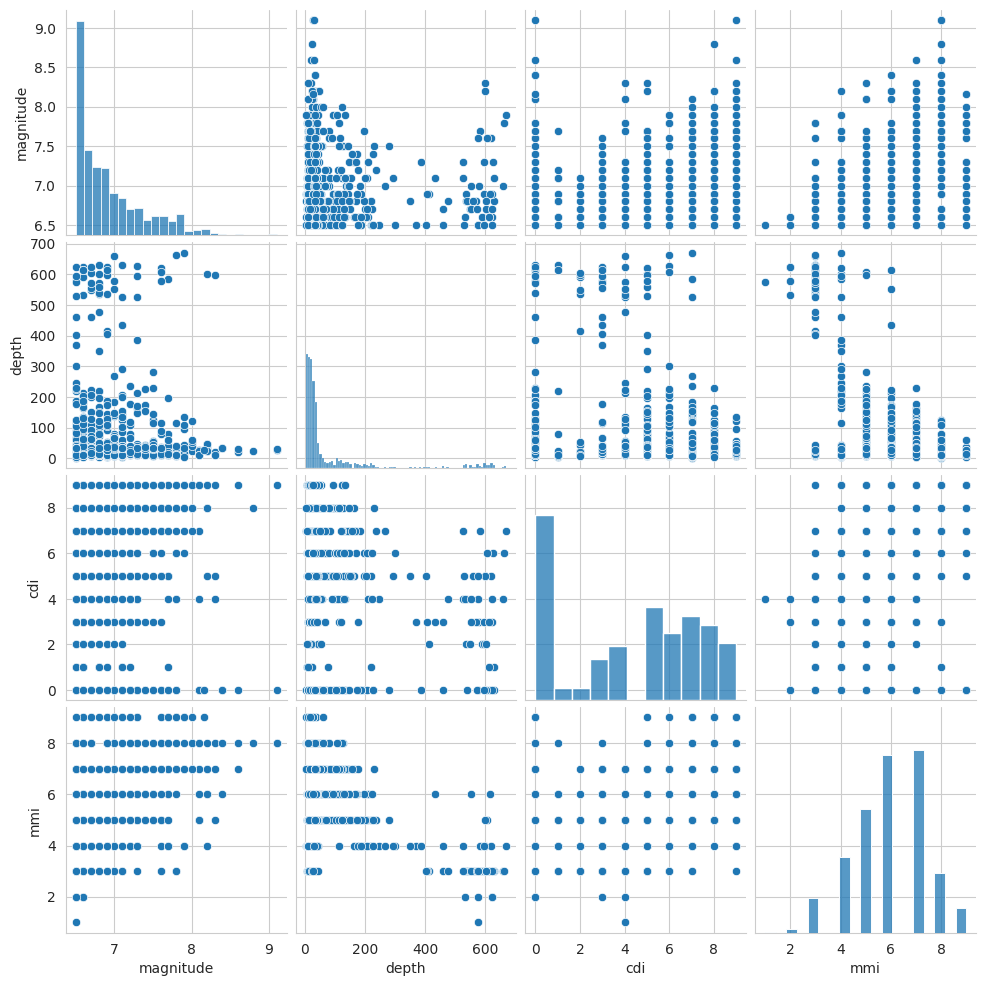

In [55]:
# ============================================================
# 10. PAIRPLOT OF EARTHQUAKE VARIABLES
# ============================================================

sns.pairplot(
    df[
        [
            "magnitude",
            "depth",
            "cdi",
            "mmi"
        ]
    ]
)

plt.show()

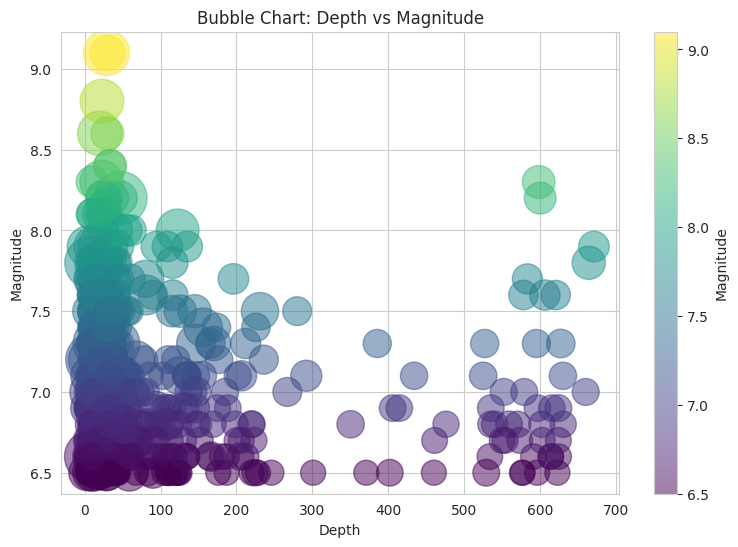

In [56]:
# ============================================================
# 11. BUBBLE CHART: DEPTH VS MAGNITUDE
# ============================================================

plt.figure(figsize=(9,6))

plt.scatter(
    df["depth"],
    df["magnitude"],
    s=df["sig"]/2,
    alpha=0.5,
    c=df["magnitude"],
    cmap="viridis"
)

plt.colorbar(label="Magnitude")

plt.xlabel("Depth")

plt.ylabel("Magnitude")

plt.title("Bubble Chart: Depth vs Magnitude")

plt.show()

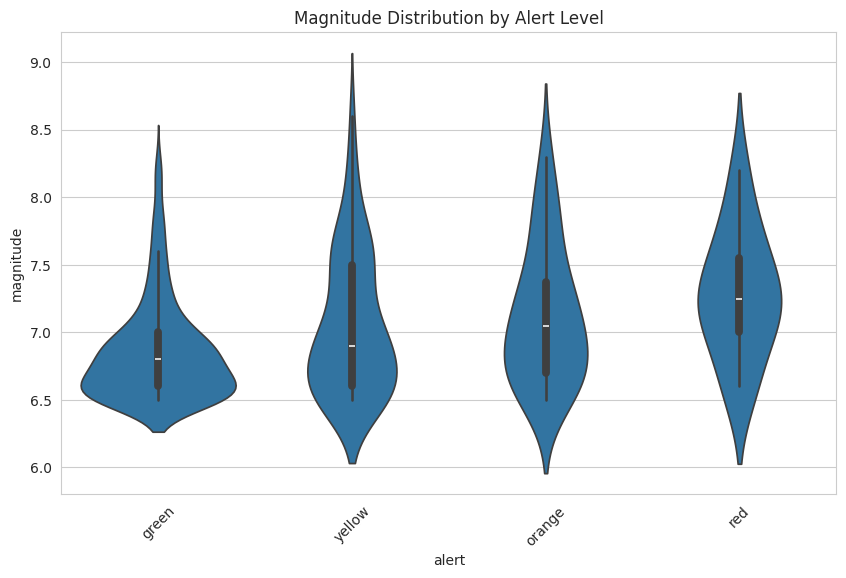

In [57]:
# ============================================================
# 12. MAGNITUDE DISTRIBUTION BY ALERT LEVEL - VIOLIN PLOT
# ============================================================

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="alert",
    y="magnitude"
)

plt.xticks(rotation=45)

plt.title("Magnitude Distribution by Alert Level")

plt.show()


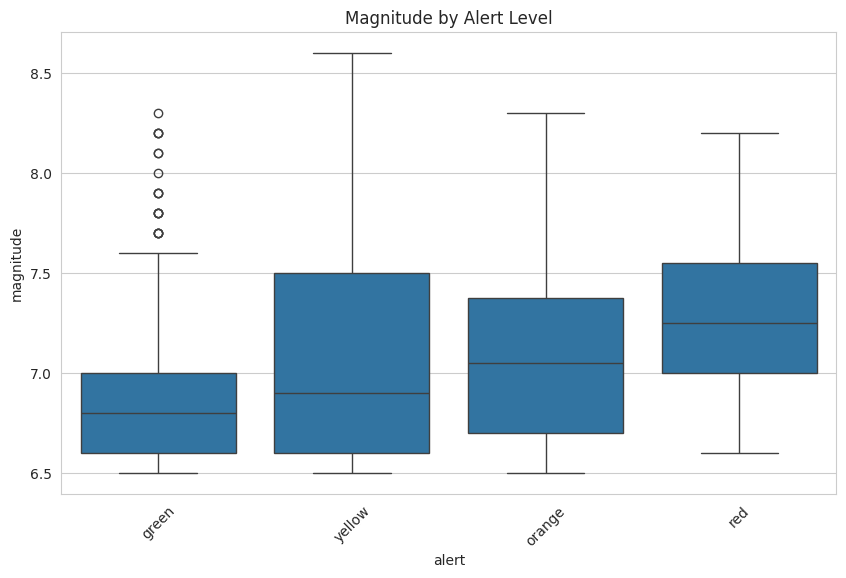

In [58]:
# ============================================================
# 13. MAGNITUDE BY ALERT LEVEL - BOXPLOT
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="alert",
    y="magnitude"
)

plt.xticks(rotation=45)

plt.title("Magnitude by Alert Level")

plt.show()